# Stage 3: Descriptive Analysis

In this notebook, I am continuing from Stage 2 cleaning and pre-processing.

The detailed data checking was already done in Stage 1, and the cleaning decisions were completed in Stage 2. So in this stage, I am only doing a short confirmation check before starting the descriptive analysis.

The aim of this stage is to understand past road traffic collision trends from 2020 to 2024. This is analysis of historical data only. I am not doing spatial preparation, hotspot scoring, grid creation or predictive modelling in this notebook.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [ ]:
# Loading the cleaned full dataset created in Stage 2

file_path = "/content/drive/MyDrive/disseration/stage2_outputs/collision_cleaned_full.csv"

df = pd.read_csv(file_path, low_memory=False)

# Just removing accidental spaces from column names
df.columns = df.columns.str.strip()

print("Cleaned dataset loaded")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Before starting the analysis, I am checking the column names because this helps me confirm that the cleaned dataset has the required variables from Stage 2.

In [ ]:
# Only a short check here because detailed checks were already done in Stage 1 and Stage 2

print("Short confirmation check")
print("------------------------")
print("Total records:", df.shape[0])
print("Total columns:", df.shape[1])

# Finding the year column safely because my cleaned dataset may use 'year' instead of 'accident_year'
if "accident_year" in df.columns:
    year_col = "accident_year"
elif "year" in df.columns:
    year_col = "year"
elif "date" in df.columns:
    df["date"] = pd.to_datetime(df["date"], errors="coerce", dayfirst=True)
    df["year"] = df["date"].dt.year
    year_col = "year"
else:
    raise KeyError("No year or date column found.")

print("Year column used:", year_col)
print("Year range:", df[year_col].min(), "to", df[year_col].max())

In [ ]:
# Creating Stage 3 output folders

stage3_folder = Path("/content/drive/MyDrive/disseration/stage3_outputs")
graphs_folder = stage3_folder / "graphs"

stage3_folder.mkdir(parents=True, exist_ok=True)
graphs_folder.mkdir(parents=True, exist_ok=True)

print("Stage 3 output folder is ready:")
print(stage3_folder)

In [ ]:
# These are the cleaned label columns created in Stage 2.
# I am setting them once so the code is easier to read later.

severity_col = "severity_label"
road_type_col = "road_type_label"
weather_col = "weather_conditions_label"
light_col = "light_conditions_label"
surface_col = "road_surface_conditions_label"
urban_rural_col = "urban_or_rural_area_label"

print("Main columns selected for Stage 3:")
print("Severity:", severity_col)
print("Road type:", road_type_col)
print("Weather:", weather_col)
print("Light:", light_col)
print("Road surface:", surface_col)
print("Urban/rural:", urban_rural_col)

Now I will start the descriptive analysis. I am beginning with time-based patterns because this helps me understand how collisions changed over the study period.

In [ ]:
# Counting collisions for each year

yearly_collision_summary = (
    df.groupby(year_col)
    .size()
    .reset_index(name="collision_count")
    .sort_values(year_col)
)

yearly_collision_summary["percentage"] = (
    yearly_collision_summary["collision_count"] / yearly_collision_summary["collision_count"].sum() * 100
).round(2)

yearly_collision_summary

In [ ]:
yearly_collision_summary.to_csv(
    stage3_folder / "yearly_collision_summary.csv",
    index=False
)

print("Yearly collision summary saved")

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    yearly_collision_summary[year_col],
    yearly_collision_summary["collision_count"],
    marker="o"
)

plt.title("Number of Road Traffic Collisions by Year")
plt.xlabel("Year")
plt.ylabel("Number of collisions")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(graphs_folder / "yearly_collision_trend.png", dpi=300)
plt.show()

The yearly graph helps me understand whether recorded collisions increased, decreased or stayed stable between 2020 and 2024.

In [ ]:
# Looking at monthly collision patterns

monthly_collision_summary = (
    df.groupby(["month", "month_name"])
    .size()
    .reset_index(name="collision_count")
    .sort_values("month")
)

monthly_collision_summary["percentage"] = (
    monthly_collision_summary["collision_count"] / monthly_collision_summary["collision_count"].sum() * 100
).round(2)

monthly_collision_summary

In [ ]:
monthly_collision_summary.to_csv(
    stage3_folder / "monthly_collision_summary.csv",
    index=False
)

print("Monthly collision summary saved")

In [ ]:
plt.figure(figsize=(10, 5))

plt.bar(
    monthly_collision_summary["month_name"],
    monthly_collision_summary["collision_count"]
)

plt.title("Number of Road Traffic Collisions by Month")
plt.xlabel("Month")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "monthly_collision_pattern.png", dpi=300)
plt.show()

In [ ]:
# I am using a fixed order so the days do not appear alphabetically

day_order = [
    "Monday", "Tuesday", "Wednesday", "Thursday",
    "Friday", "Saturday", "Sunday"
]

day_collision_summary = (
    df["day_name"]
    .value_counts()
    .reindex(day_order)
    .reset_index()
)

day_collision_summary.columns = ["day_name", "collision_count"]

day_collision_summary["percentage"] = (
    day_collision_summary["collision_count"] / day_collision_summary["collision_count"].sum() * 100
).round(2)

day_collision_summary

In [ ]:
day_collision_summary.to_csv(
    stage3_folder / "day_collision_summary.csv",
    index=False
)

print("Day collision summary saved")

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    day_collision_summary["day_name"],
    day_collision_summary["collision_count"]
)

plt.title("Number of Road Traffic Collisions by Day of Week")
plt.xlabel("Day of week")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "day_collision_pattern.png", dpi=300)
plt.show()

In [ ]:
# Checking hourly collision pattern

hourly_collision_summary = (
    df.groupby("hour")
    .size()
    .reset_index(name="collision_count")
    .sort_values("hour")
)

hourly_collision_summary["percentage"] = (
    hourly_collision_summary["collision_count"] / hourly_collision_summary["collision_count"].sum() * 100
).round(2)

hourly_collision_summary

In [ ]:
hourly_collision_summary.to_csv(
    stage3_folder / "hourly_collision_summary.csv",
    index=False
)

print("Hourly collision summary saved")

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    hourly_collision_summary["hour"],
    hourly_collision_summary["collision_count"],
    marker="o"
)

plt.title("Number of Road Traffic Collisions by Hour")
plt.xlabel("Hour of day")
plt.ylabel("Number of collisions")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(graphs_folder / "hourly_collision_pattern.png", dpi=300)
plt.show()

The hourly graph is useful because collisions may be affected by daily travel patterns, such as school time, work commuting and evening traffic.

In [ ]:
# Checking how many collisions are fatal, serious or slight

severity_summary = (
    df[severity_col]
    .value_counts(dropna=False)
    .reset_index()
)

severity_summary.columns = ["severity", "collision_count"]

severity_summary["percentage"] = (
    severity_summary["collision_count"] / severity_summary["collision_count"].sum() * 100
).round(2)

severity_summary

In [ ]:
severity_summary.to_csv(
    stage3_folder / "severity_summary.csv",
    index=False
)

print("Severity summary saved")

In [ ]:
plt.figure(figsize=(7, 5))

plt.bar(
    severity_summary["severity"].astype(str),
    severity_summary["collision_count"]
)

plt.title("Collision Severity Distribution")
plt.xlabel("Severity")
plt.ylabel("Number of collisions")
plt.tight_layout()

plt.savefig(graphs_folder / "severity_distribution.png", dpi=300)
plt.show()

In [ ]:
# Comparing severity across different years

severity_by_year_summary = pd.crosstab(
    df[year_col],
    df[severity_col]
)

severity_by_year_summary["total_collisions"] = severity_by_year_summary.sum(axis=1)

severity_by_year_summary = severity_by_year_summary.reset_index()

severity_by_year_summary

In [ ]:
severity_by_year_summary.to_csv(
    stage3_folder / "severity_by_year_summary.csv",
    index=False
)

print("Severity by year summary saved")

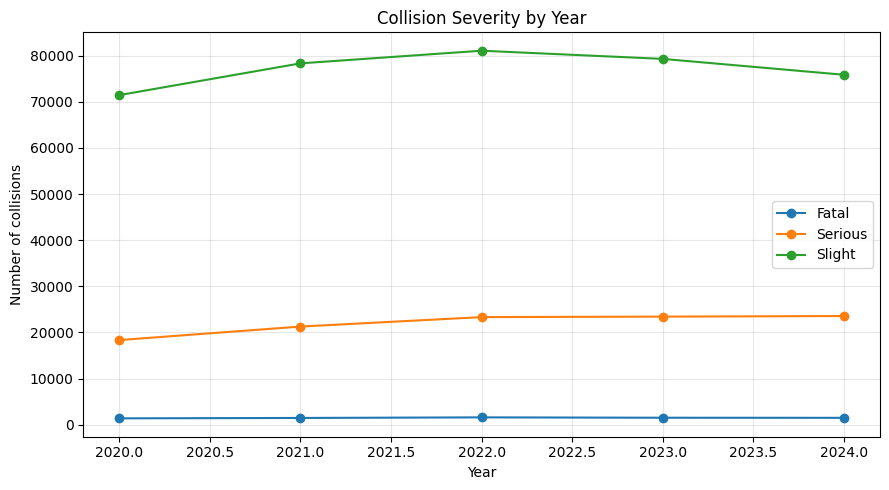

In [25]:
plt.figure(figsize=(9, 5))

for col in severity_by_year_summary.columns:
    if col not in [year_col, "total_collisions"]:
        plt.plot(
            severity_by_year_summary[year_col],
            severity_by_year_summary[col],
            marker="o",
            label=col
        )

plt.title("Collision Severity by Year")
plt.xlabel("Year")
plt.ylabel("Number of collisions")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig(graphs_folder / "severity_by_year.png", dpi=300)
plt.show()

In [26]:
# Looking at which road types have the highest number of recorded collisions

road_type_summary = (
    df[road_type_col]
    .value_counts(dropna=False)
    .reset_index()
)

road_type_summary.columns = ["road_type", "collision_count"]

road_type_summary["percentage"] = (
    road_type_summary["collision_count"] / road_type_summary["collision_count"].sum() * 100
).round(2)

road_type_summary

,road_type,collision_count,percentage
0,Single carriageway,365844,72.66
1,Dual carriageway,74715,14.84
2,Roundabout,29963,5.95
3,Unknown,13113,2.60
4,One way street,11118,2.21
5,Slip road,8722,1.73


In [27]:
road_type_summary.to_csv(
    stage3_folder / "road_type_summary.csv",
    index=False
)

print("Road type summary saved")

Road type summary saved


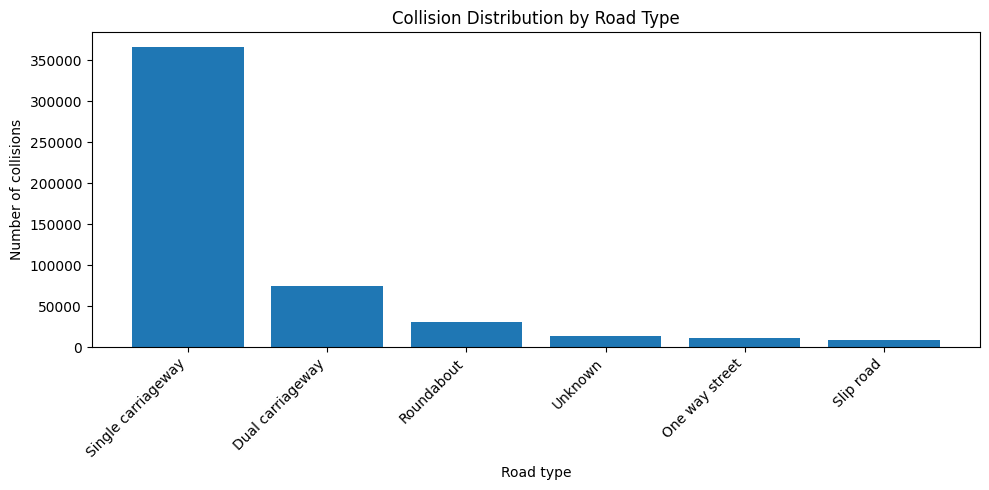

In [28]:
plt.figure(figsize=(10, 5))

plt.bar(
    road_type_summary["road_type"].astype(str),
    road_type_summary["collision_count"]
)

plt.title("Collision Distribution by Road Type")
plt.xlabel("Road type")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "road_type_distribution.png", dpi=300)
plt.show()

In [29]:
# Looking at collision counts by speed limit

speed_limit_summary = (
    df["speed_limit"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

speed_limit_summary.columns = ["speed_limit", "collision_count"]

speed_limit_summary["percentage"] = (
    speed_limit_summary["collision_count"] / speed_limit_summary["collision_count"].sum() * 100
).round(2)

speed_limit_summary

,speed_limit,collision_count,percentage
0,-1,15,0.00
1,20,79234,15.74
2,30,269912,53.61
3,40,43731,8.69
4,50,21836,4.34
5,60,61402,12.20
6,70,27345,5.43


In [30]:
speed_limit_summary.to_csv(
    stage3_folder / "speed_limit_summary.csv",
    index=False
)

print("Speed limit summary saved")

Speed limit summary saved


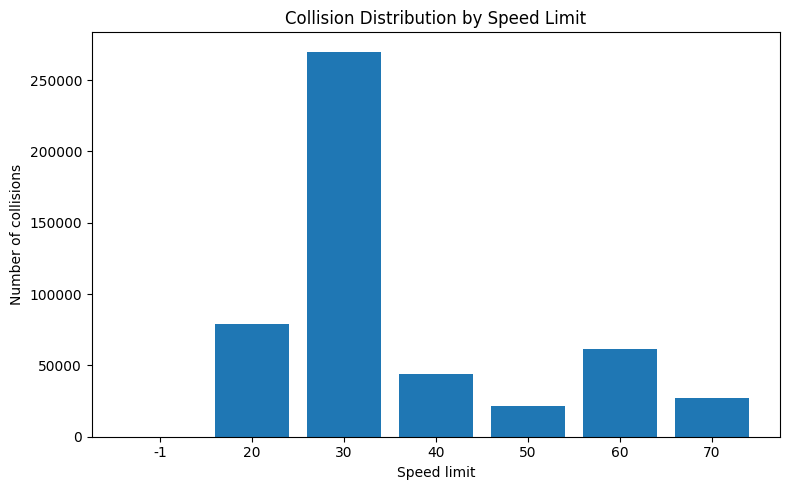

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    speed_limit_summary["speed_limit"].astype(str),
    speed_limit_summary["collision_count"]
)

plt.title("Collision Distribution by Speed Limit")
plt.xlabel("Speed limit")
plt.ylabel("Number of collisions")
plt.tight_layout()

plt.savefig(graphs_folder / "speed_limit_distribution.png", dpi=300)
plt.show()

In [32]:
# These are the main columns I need for Stage 3.
# Some columns may have slightly different names, so I am selecting them safely.

def find_column(possible_names):
    for name in possible_names:
        if name in df.columns:
            return name
    return None


severity_col = find_column([
    "severity_label",
    "accident_severity_label",
    "accident_severity"
])

road_type_col = find_column([
    "road_type_label",
    "road_type"
])

weather_col = find_column([
    "weather_conditions_label",
    "weather_condition_label",
    "weather_conditions",
    "weather_condition"
])

light_col = find_column([
    "light_conditions_label",
    "light_condition_label",
    "light_conditions",
    "light_condition"
])

surface_col = find_column([
    "road_surface_conditions_label",
    "road_surface_condition_label",
    "road_surface_conditions",
    "road_surface_condition"
])

urban_rural_col = find_column([
    "urban_or_rural_area_label",
    "urban_rural_label",
    "urban_or_rural_area",
    "urban_rural_area"
])

print("Columns selected for Stage 3:")
print("Severity:", severity_col)
print("Road type:", road_type_col)
print("Weather:", weather_col)
print("Light:", light_col)
print("Road surface:", surface_col)
print("Urban/rural:", urban_rural_col)

Columns selected for Stage 3:
Severity: severity_label
Road type: road_type_label
Weather: weather_conditions
Light: light_conditions
Road surface: road_surface_conditions
Urban/rural: urban_rural_label


In [33]:
# If some columns are still coded numbers, I will create readable versions for analysis.

severity_map = {
    1: "Fatal",
    2: "Serious",
    3: "Slight",
    "1": "Fatal",
    "2": "Serious",
    "3": "Slight"
}

road_type_map = {
    1: "Roundabout",
    2: "One way street",
    3: "Dual carriageway",
    6: "Single carriageway",
    7: "Slip road",
    9: "Unknown",
    12: "One way street / Slip road",
    -1: "Data missing or out of range",
    "-1": "Data missing or out of range"
}

weather_map = {
    1: "Fine no high winds",
    2: "Raining no high winds",
    3: "Snowing no high winds",
    4: "Fine and high winds",
    5: "Raining and high winds",
    6: "Snowing and high winds",
    7: "Fog or mist",
    8: "Other",
    9: "Unknown",
    -1: "Data missing or out of range",
    "-1": "Data missing or out of range"
}

light_map = {
    1: "Daylight",
    4: "Darkness: lights lit",
    5: "Darkness: lights unlit",
    6: "Darkness: no lighting",
    7: "Darkness: lighting unknown",
    -1: "Data missing or out of range",
    "-1": "Data missing or out of range"
}

surface_map = {
    1: "Dry",
    2: "Wet or damp",
    3: "Snow",
    4: "Frost or ice",
    5: "Flood over 3cm deep",
    6: "Oil or diesel",
    7: "Mud",
    -1: "Data missing or out of range",
    "-1": "Data missing or out of range"
}

urban_rural_map = {
    1: "Urban",
    2: "Rural",
    3: "Unallocated",
    -1: "Data missing or out of range",
    "-1": "Data missing or out of range"
}


def make_readable_column(original_col, new_col, mapping):
    if original_col is None:
        return None

    df[new_col] = df[original_col].map(mapping).fillna(df[original_col])
    df[new_col] = df[new_col].fillna("Unknown").astype(str)

    return new_col


severity_col = make_readable_column(severity_col, "severity_for_analysis", severity_map)
road_type_col = make_readable_column(road_type_col, "road_type_for_analysis", road_type_map)
weather_col = make_readable_column(weather_col, "weather_for_analysis", weather_map)
light_col = make_readable_column(light_col, "light_for_analysis", light_map)
surface_col = make_readable_column(surface_col, "surface_for_analysis", surface_map)
urban_rural_col = make_readable_column(urban_rural_col, "urban_rural_for_analysis", urban_rural_map)

print("Final columns used in analysis:")
print("Severity:", severity_col)
print("Road type:", road_type_col)
print("Weather:", weather_col)
print("Light:", light_col)
print("Road surface:", surface_col)
print("Urban/rural:", urban_rural_col)

Final columns used in analysis:
Severity: severity_for_analysis
Road type: road_type_for_analysis
Weather: weather_for_analysis
Light: light_for_analysis
Road surface: surface_for_analysis
Urban/rural: urban_rural_for_analysis


In [34]:
weather_summary = (
    df[weather_col]
    .value_counts(dropna=False)
    .reset_index()
)

weather_summary.columns = ["weather_condition", "collision_count"]

weather_summary["percentage"] = (
    weather_summary["collision_count"] / weather_summary["collision_count"].sum() * 100
).round(2)

weather_summary

,weather_condition,collision_count,percentage
0,Fine no high winds,400956,79.64
1,Raining no high winds,57187,11.36
2,Other,15270,3.03
3,Unknown,14604,2.90
4,Raining and high winds,5958,1.18
5,Fine and high winds,5158,1.02
6,Fog or mist,2296,0.46
7,Snowing no high winds,1741,0.35
8,Snowing and high winds,292,0.06
9,Data missing or out of range,13,0.00


In [35]:
weather_summary.to_csv(
    stage3_folder / "weather_summary.csv",
    index=False
)

print("Weather summary saved")

Weather summary saved


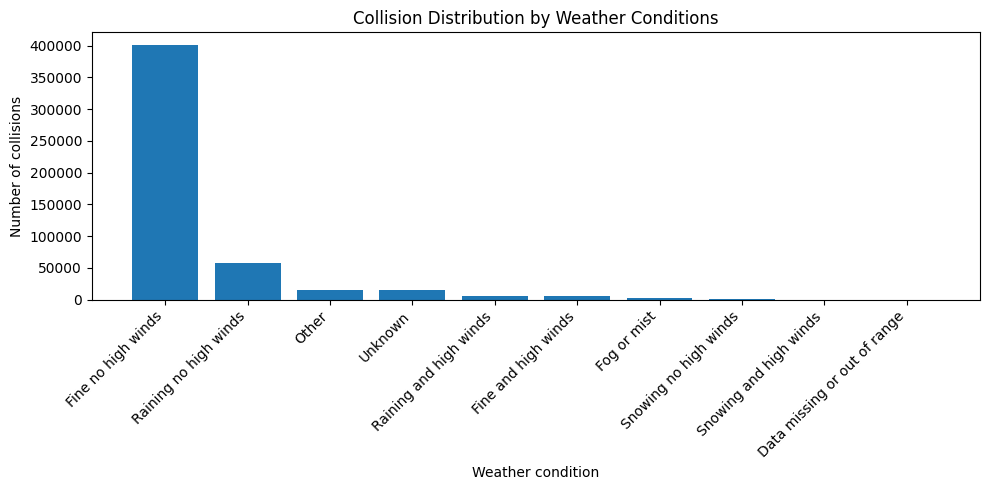

In [36]:
plt.figure(figsize=(10, 5))

plt.bar(
    weather_summary["weather_condition"].astype(str),
    weather_summary["collision_count"]
)

plt.title("Collision Distribution by Weather Conditions")
plt.xlabel("Weather condition")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "weather_conditions_distribution.png", dpi=300)
plt.show()

In [37]:
# Checking collision distribution across light conditions

light_condition_summary = (
    df[light_col]
    .value_counts(dropna=False)
    .reset_index()
)

light_condition_summary.columns = ["light_condition", "collision_count"]

light_condition_summary["percentage"] = (
    light_condition_summary["collision_count"] / light_condition_summary["collision_count"].sum() * 100
).round(2)

light_condition_summary

,light_condition,collision_count,percentage
0,Daylight,359837,71.47
1,Darkness: lights lit,104155,20.69
2,Darkness: no lighting,26591,5.28
3,Darkness: lighting unknown,9202,1.83
4,Darkness: lights unlit,3671,0.73
5,Data missing or out of range,19,0.00


In [38]:
light_condition_summary.to_csv(
    stage3_folder / "light_condition_summary.csv",
    index=False
)

print("Light condition summary saved")

Light condition summary saved


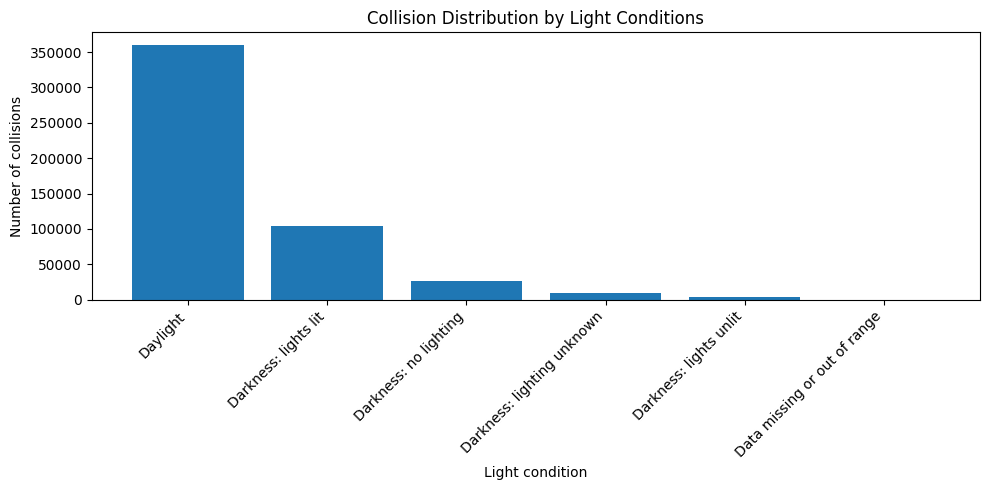

In [39]:
plt.figure(figsize=(10, 5))

plt.bar(
    light_condition_summary["light_condition"].astype(str),
    light_condition_summary["collision_count"]
)

plt.title("Collision Distribution by Light Conditions")
plt.xlabel("Light condition")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "light_condition_distribution.png", dpi=300)
plt.show()

In [40]:
# Checking collision distribution across road surface conditions

road_surface_summary = (
    df[surface_col]
    .value_counts(dropna=False)
    .reset_index()
)

road_surface_summary.columns = ["road_surface_condition", "collision_count"]

road_surface_summary["percentage"] = (
    road_surface_summary["collision_count"] / road_surface_summary["collision_count"].sum() * 100
).round(2)

road_surface_summary

,road_surface_condition,collision_count,percentage
0,Dry,361287,71.76
1,Wet or damp,124500,24.73
2,9,6226,1.24
3,Frost or ice,6171,1.23
4,Data missing or out of range,3209,0.64
5,Snow,1261,0.25
6,Flood over 3cm deep,821,0.16


In [41]:
road_surface_summary.to_csv(
    stage3_folder / "road_surface_summary.csv",
    index=False
)

print("Road surface summary saved")

Road surface summary saved


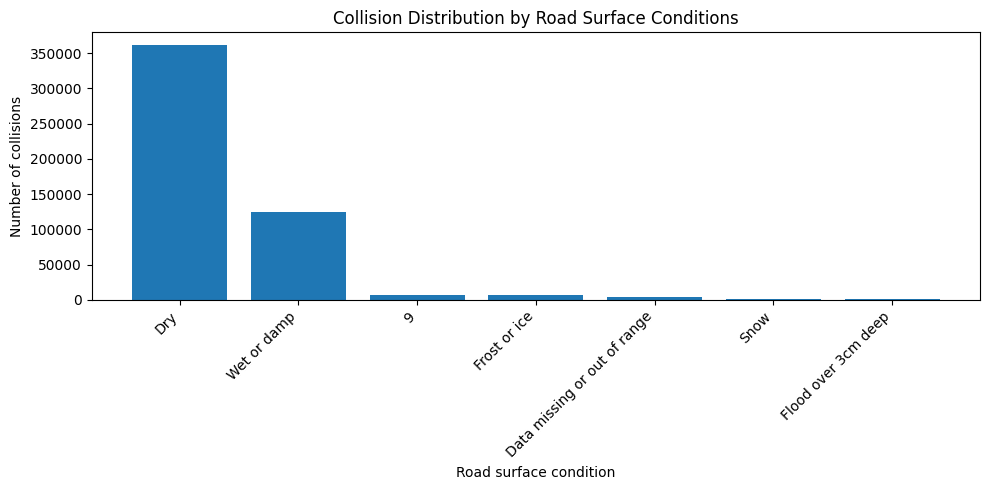

In [42]:
plt.figure(figsize=(10, 5))

plt.bar(
    road_surface_summary["road_surface_condition"].astype(str),
    road_surface_summary["collision_count"]
)

plt.title("Collision Distribution by Road Surface Conditions")
plt.xlabel("Road surface condition")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "road_surface_distribution.png", dpi=300)
plt.show()

In [44]:
# Checking whether most collisions were recorded in urban or rural areas

urban_rural_summary = (
    df[urban_rural_col]
    .value_counts(dropna=False)
    .reset_index()
)

urban_rural_summary.columns = ["urban_rural_area", "collision_count"]

urban_rural_summary["percentage"] = (
    urban_rural_summary["collision_count"] / urban_rural_summary["collision_count"].sum() * 100
).round(2)

urban_rural_summary
urban_rural_summary.to_csv(
    stage3_folder / "urban_rural_summary.csv",
    index=False
)

print("Urban/rural summary saved")

Urban/rural summary saved


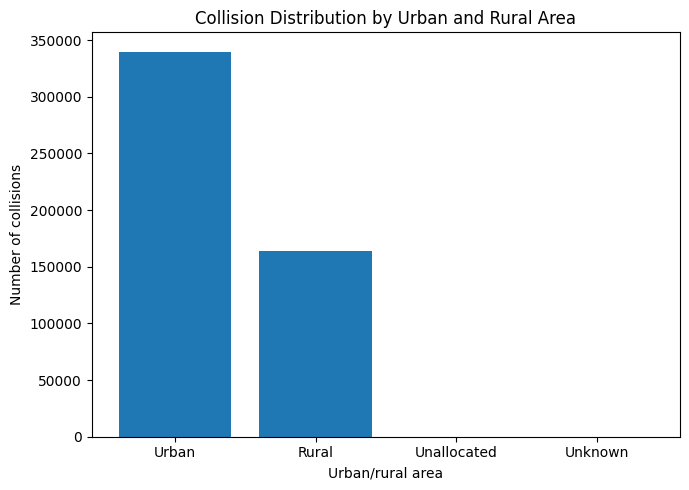

In [45]:
plt.figure(figsize=(7, 5))

plt.bar(
    urban_rural_summary["urban_rural_area"].astype(str),
    urban_rural_summary["collision_count"]
)

plt.title("Collision Distribution by Urban and Rural Area")
plt.xlabel("Urban/rural area")
plt.ylabel("Number of collisions")
plt.tight_layout()

plt.savefig(graphs_folder / "urban_rural_distribution.png", dpi=300)
plt.show()

After checking the main distributions, I am now comparing severity with road and environmental conditions. This is still descriptive analysis because I am only comparing historical collision records.

Severity by Road Type

In [48]:
severity_by_road_type_summary = pd.crosstab(
    df[road_type_col],
    df[severity_col]
)

severity_by_road_type_summary["total_collisions"] = severity_by_road_type_summary.sum(axis=1)

severity_by_road_type_summary = severity_by_road_type_summary.sort_values(
    "total_collisions",
    ascending=False
)

severity_by_road_type_summary

severity_by_road_type_summary.to_csv(
    stage3_folder / "severity_by_road_type_summary.csv"
)

print("Severity by road type summary saved")

Severity by road type summary saved


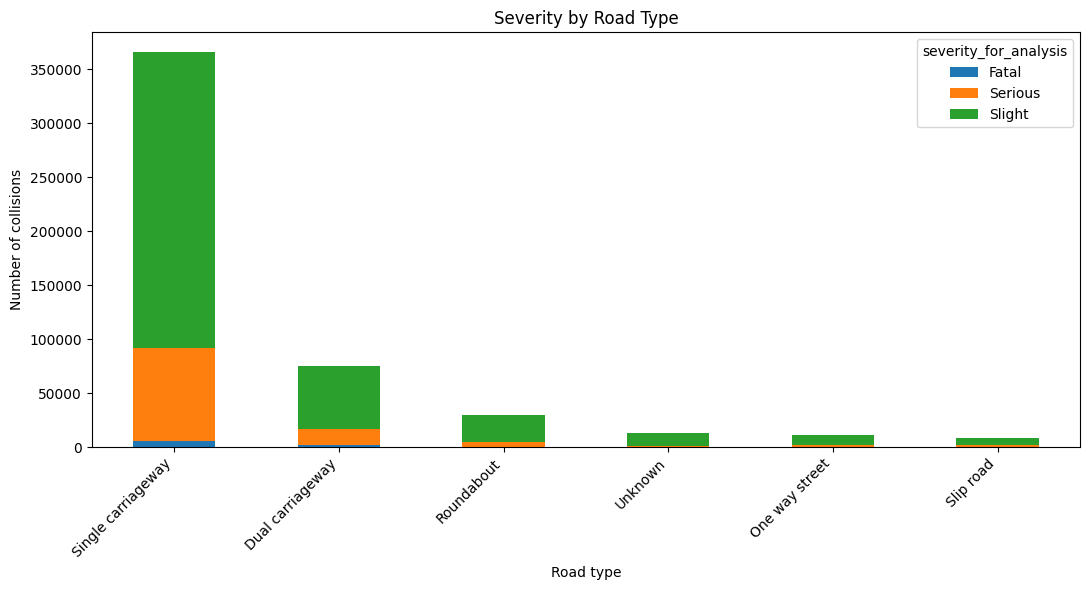

In [49]:
severity_by_road_type_summary.drop(columns="total_collisions").head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Severity by Road Type")
plt.xlabel("Road type")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "severity_by_road_type.png", dpi=300)
plt.show()

Severity by Weather

In [50]:
severity_by_weather_summary = pd.crosstab(
    df[weather_col],
    df[severity_col]
)

severity_by_weather_summary["total_collisions"] = severity_by_weather_summary.sum(axis=1)

severity_by_weather_summary = severity_by_weather_summary.sort_values(
    "total_collisions",
    ascending=False
)

severity_by_weather_summary

severity_for_analysis,Fatal,Serious,Slight,total_collisions
weather_for_analysis,,,,
Fine no high winds,6169,89539,305248,400956
Raining no high winds,775,12269,44143,57187
Other,119,2787,12364,15270
Unknown,56,1672,12876,14604
Raining and high winds,149,1384,4425,5958
Fine and high winds,133,1343,3682,5158
Fog or mist,67,559,1670,2296
Snowing no high winds,19,365,1357,1741
Snowing and high winds,1,59,232,292


In [51]:
severity_by_weather_summary.to_csv(
    stage3_folder / "severity_by_weather_summary.csv"
)

print("Severity by weather summary saved")

Severity by weather summary saved


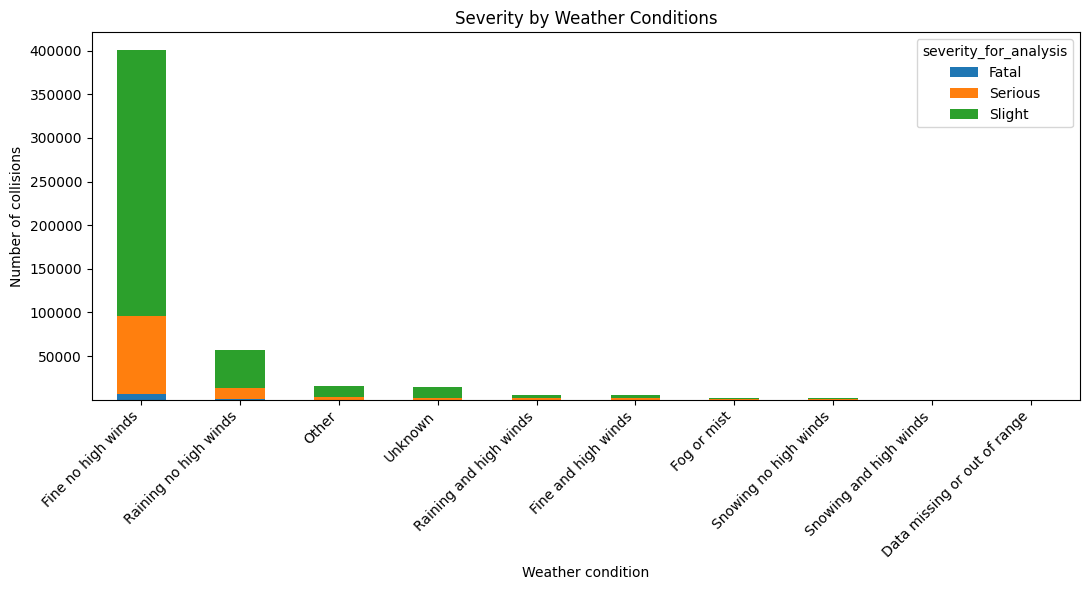

In [52]:
severity_by_weather_summary.drop(columns="total_collisions").head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Severity by Weather Conditions")
plt.xlabel("Weather condition")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "severity_by_weather.png", dpi=300)
plt.show()

Severity by Light Conditions

In [53]:
severity_by_light_summary = pd.crosstab(
    df[light_col],
    df[severity_col]
)

severity_by_light_summary["total_collisions"] = severity_by_light_summary.sum(axis=1)

severity_by_light_summary = severity_by_light_summary.sort_values(
    "total_collisions",
    ascending=False
)

severity_by_light_summary

severity_for_analysis,Fatal,Serious,Slight,total_collisions
light_for_analysis,,,,
Daylight,4361,76044,279432,359837
Darkness: lights lit,1581,23688,78886,104155
Darkness: no lighting,1306,7798,17487,26591
Darkness: lighting unknown,143,1498,7561,9202
Darkness: lights unlit,97,945,2629,3671
Data missing or out of range,3,4,12,19


In [54]:
severity_by_light_summary.to_csv(
    stage3_folder / "severity_by_light_condition_summary.csv"
)

print("Severity by light condition summary saved")

Severity by light condition summary saved


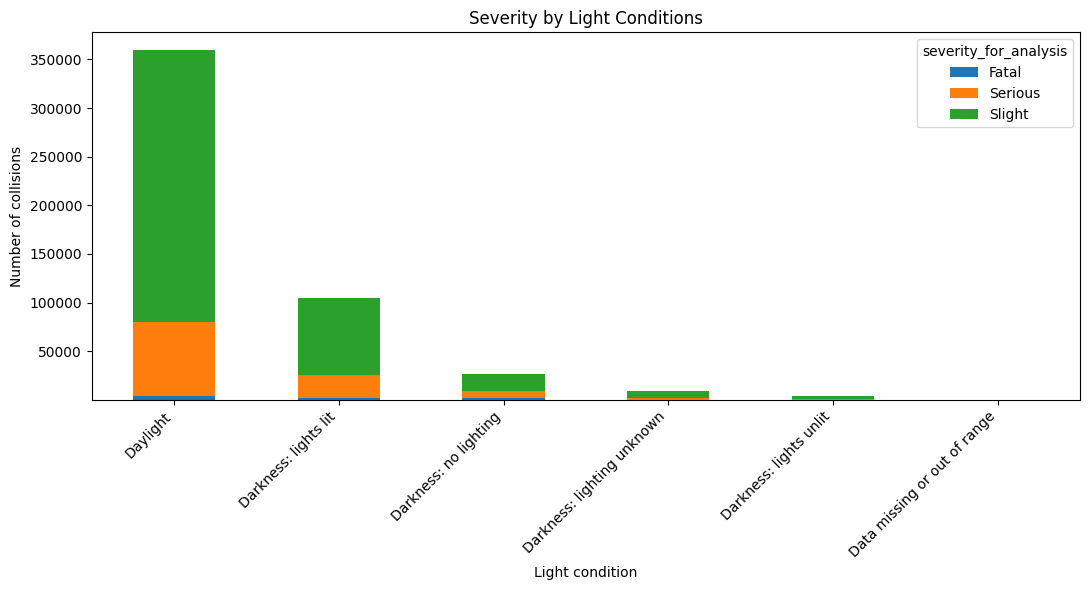

In [55]:
severity_by_light_summary.drop(columns="total_collisions").head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Severity by Light Conditions")
plt.xlabel("Light condition")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "severity_by_light_condition.png", dpi=300)
plt.show()

Severity by Road Surface

In [56]:
severity_by_surface_summary = pd.crosstab(
    df[surface_col],
    df[severity_col]
)

severity_by_surface_summary["total_collisions"] = severity_by_surface_summary.sum(axis=1)

severity_by_surface_summary = severity_by_surface_summary.sort_values(
    "total_collisions",
    ascending=False
)

severity_by_surface_summary

severity_for_analysis,Fatal,Serious,Slight,total_collisions
surface_for_analysis,,,,
Dry,5166,79408,276713,361287
Wet or damp,2203,28027,94270,124500
9,3,422,5801,6226
Frost or ice,73,1302,4796,6171
Data missing or out of range,12,370,2827,3209
Snow,12,261,988,1261
Flood over 3cm deep,22,187,612,821


In [57]:
severity_by_surface_summary.to_csv(
    stage3_folder / "severity_by_road_surface_summary.csv"
)

print("Severity by road surface summary saved")

Severity by road surface summary saved


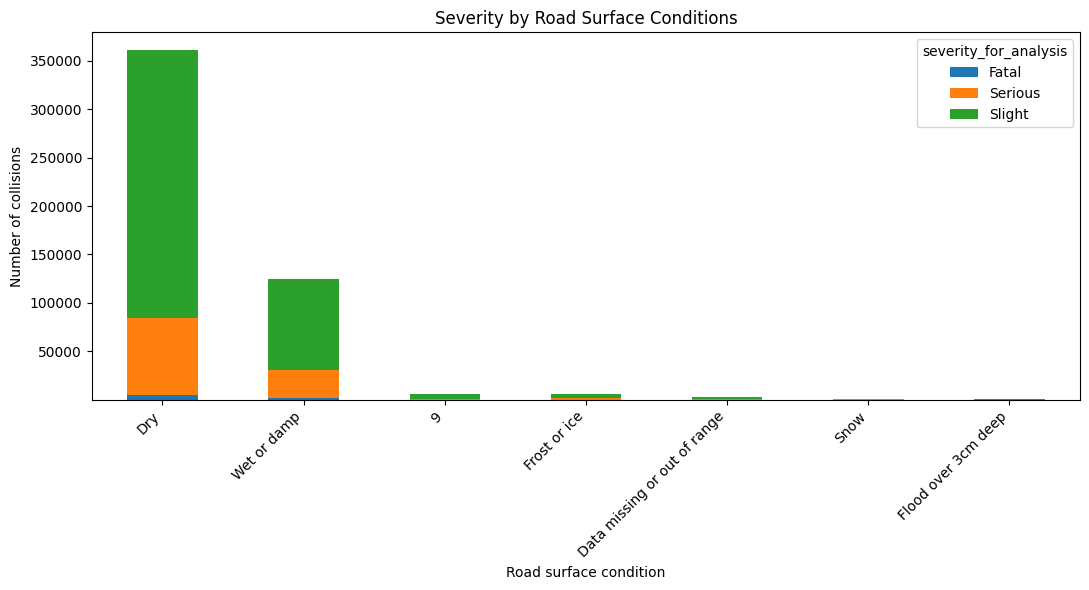

In [58]:
severity_by_surface_summary.drop(columns="total_collisions").head(10).plot(
    kind="bar",
    stacked=True,
    figsize=(11, 6)
)

plt.title("Severity by Road Surface Conditions")
plt.xlabel("Road surface condition")
plt.ylabel("Number of collisions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig(graphs_folder / "severity_by_road_surface.png", dpi=300)
plt.show()

Severity by Urban/Rural Area

In [59]:
severity_by_urban_rural_summary = pd.crosstab(
    df[urban_rural_col],
    df[severity_col]
)

severity_by_urban_rural_summary["total_collisions"] = severity_by_urban_rural_summary.sum(axis=1)

severity_by_urban_rural_summary = severity_by_urban_rural_summary.sort_values(
    "total_collisions",
    ascending=False
)

severity_by_urban_rural_summary

severity_for_analysis,Fatal,Serious,Slight,total_collisions
urban_rural_for_analysis,,,,
Urban,2792,67620,269491,339903
Rural,4698,42340,116466,163504
Unallocated,1,15,44,60
Unknown,0,2,6,8


In [60]:
severity_by_urban_rural_summary.to_csv(
    stage3_folder / "severity_by_urban_rural_summary.csv"
)

print("Severity by urban/rural summary saved")

Severity by urban/rural summary saved


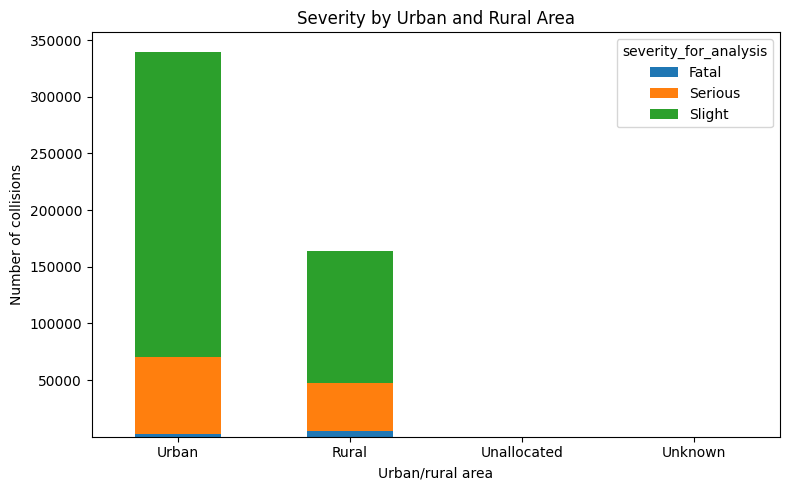

In [61]:
severity_by_urban_rural_summary.drop(columns="total_collisions").plot(
    kind="bar",
    stacked=True,
    figsize=(8, 5)
)

plt.title("Severity by Urban and Rural Area")
plt.xlabel("Urban/rural area")
plt.ylabel("Number of collisions")
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(graphs_folder / "severity_by_urban_rural.png", dpi=300)
plt.show()

In [62]:
# I am making a small summary table from the main descriptive results.
# This will help me when writing the Stage 3 explanation in the dissertation.

highest_year = yearly_collision_summary.sort_values("collision_count", ascending=False).iloc[0]
lowest_year = yearly_collision_summary.sort_values("collision_count", ascending=True).iloc[0]

highest_month = monthly_collision_summary.sort_values("collision_count", ascending=False).iloc[0]
highest_day = day_collision_summary.sort_values("collision_count", ascending=False).iloc[0]
highest_hour = hourly_collision_summary.sort_values("collision_count", ascending=False).iloc[0]

most_common_severity = severity_summary.sort_values("collision_count", ascending=False).iloc[0]
most_common_road_type = road_type_summary.sort_values("collision_count", ascending=False).iloc[0]
most_common_weather = weather_summary.sort_values("collision_count", ascending=False).iloc[0]
most_common_light = light_condition_summary.sort_values("collision_count", ascending=False).iloc[0]
most_common_surface = road_surface_summary.sort_values("collision_count", ascending=False).iloc[0]
most_common_urban_rural = urban_rural_summary.sort_values("collision_count", ascending=False).iloc[0]

stage3_descriptive_summary = pd.DataFrame({
    "analysis_area": [
        "Dataset used",
        "Rows analysed",
        "Columns in dataset",
        "Year range",
        "Highest collision year",
        "Lowest collision year",
        "Highest collision month",
        "Highest collision day",
        "Highest collision hour",
        "Most common severity",
        "Most common road type",
        "Most common weather condition",
        "Most common light condition",
        "Most common road surface condition",
        "Most common urban/rural area"
    ],
    "finding": [
        "collision_cleaned_full.csv",
        df.shape[0],
        df.shape[1],
        f"{df[year_col].min()} to {df[year_col].max()}",
        f"{int(highest_year[year_col])} with {int(highest_year['collision_count'])} collisions",
        f"{int(lowest_year[year_col])} with {int(lowest_year['collision_count'])} collisions",
        f"{highest_month['month_name']} with {int(highest_month['collision_count'])} collisions",
        f"{highest_day['day_name']} with {int(highest_day['collision_count'])} collisions",
        f"{int(highest_hour['hour'])}:00 with {int(highest_hour['collision_count'])} collisions",
        f"{most_common_severity['severity']} with {int(most_common_severity['collision_count'])} collisions",
        f"{most_common_road_type['road_type']} with {int(most_common_road_type['collision_count'])} collisions",
        f"{most_common_weather['weather_condition']} with {int(most_common_weather['collision_count'])} collisions",
        f"{most_common_light['light_condition']} with {int(most_common_light['collision_count'])} collisions",
        f"{most_common_surface['road_surface_condition']} with {int(most_common_surface['collision_count'])} collisions",
        f"{most_common_urban_rural['urban_rural_area']} with {int(most_common_urban_rural['collision_count'])} collisions"
    ]
})

stage3_descriptive_summary

,analysis_area,finding
0,Dataset used,collision_cleaned_full.csv
1,Rows analysed,503475
2,Columns in dataset,70
3,Year range,2020 to 2024
4,Highest collision year,2022 with 106004 collisions
5,Lowest collision year,2020 with 91199 collisions
6,Highest collision month,October with 46122 collisions
7,Highest collision day,Friday with 83389 collisions
8,Highest collision hour,17:00 with 43728 collisions
9,Most common severity,Slight with 386007 collisions


In [63]:
stage3_descriptive_summary.to_csv(
    stage3_folder / "stage3_descriptive_summary.csv",
    index=False
)

print("Stage 3 descriptive summary saved")

Stage 3 descriptive summary saved


In [64]:
stage3_descriptive_summary.to_csv(
    stage3_folder / "stage3_descriptive_summary.csv",
    index=False
)

print("Stage 3 descriptive summary saved")

Stage 3 descriptive summary saved


In [65]:
print("Graphs saved in Stage 3 graphs folder:")

for file in sorted(graphs_folder.glob("*.png")):
    print("-", file.name)

Graphs saved in Stage 3 graphs folder:
- day_collision_pattern.png
- hourly_collision_pattern.png
- light_condition_distribution.png
- monthly_collision_pattern.png
- road_surface_distribution.png
- road_type_distribution.png
- severity_by_light_condition.png
- severity_by_road_surface.png
- severity_by_road_type.png
- severity_by_urban_rural.png
- severity_by_weather.png
- severity_by_year.png
- severity_distribution.png
- speed_limit_distribution.png
- urban_rural_distribution.png
- weather_conditions_distribution.png
- yearly_collision_trend.png


# End of Stage 3

Stage 3 is completed. In this notebook, I analysed past collision trends using the cleaned full dataset from Stage 2.

The analysis covered collision patterns by year, month, day, hour, severity, road type, speed limit, weather, lighting, road surface and urban/rural area.

The saved CSV summaries and PNG graphs will be used later in the dissertation when explaining historical collision trends before moving into spatial preparation and hotspot analysis.